In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
energies = collect(range(0, 100, length=1000*100));
lattice_vectors = loadlattice("wannier.out");
epsilons = zeros(100, 100);
kpoints = bandstructkpoints2q(interpolate=5);
landau_lower = zeros(60);
landau_upper = zeros(60);

In [4]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");

In [5]:
EsUp, _ = wannier_bands(HwannierUp, cell_mapUp, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));
EsDn, _ = wannier_bands(HwannierDn, cell_mapDn, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));

In [6]:
np.savetxt("EsUp.txt", EsUp)
np.savetxt("EsDn.txt", EsDn)

In [7]:
EnergiesUp, DOSUp = density_of_states(HwannierUp, cell_mapUp, Val(2), histogram_width=1000, mesh=20, monte_carlo=true, num_blocks=100)
EnergiesDn, DOSDn = density_of_states(HwannierDn, cell_mapDn, Val(2), histogram_width=1000, mesh=20, monte_carlo=true, num_blocks=100)

([-24.42349060095513, -24.422490614154146, -24.421490627353162, -24.420490640552178, -24.419490653751193, -24.418490666950206, -24.41749068014922, -24.416490693348237, -24.415490706547253, -24.41449071974627  …  5.255117665466738, 5.256117652267722, 5.257117639068706, 5.258117625869691, 5.259117612670675, 5.260117599471659, 5.261117586272647, 5.262117573073631, 5.263117559874615, 5.2641175466756], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [8]:
np.savetxt("DosUp.txt", hcat(EnergiesUp, DOSUp))
np.savetxt("DosDn.txt", hcat(EnergiesDn, DOSDn))

In [6]:
for (i, k) in enumerate(kpoints[1:100])
    i == 1 && continue
    polarization = parse.(Float64, readlines("Plasmon.out-$i"))
    for (j, ω) in enumerate(range(0.05, 0.5, length=100))
        epsilons[i, j] = imag(1 / ϵ(k, lattice_vectors, ω, energies, polarization, δ=0.001))
    end
end

In [11]:
plasmon = [range(0.05, 0.5, length=100)[argmax(x)] for x in eachrow(log.(abs.(epsilons[2:50, :])))]
plasmon = smooth([0, plasmon...], win_len=1)
plasmon = [plasmon[1:5]..., smooth(plasmon[6:end], win_len=10)...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon);
confinements[1] = 0;

In [13]:
for (i, k) in enumerate(kpoints[1:50])
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    non_zero_impols = energies[findall(.!iszero.(polarizations))]
    landau_lower[i] = maximum([filter(x-> x < plasmon[i], non_zero_impols)..., 0])
    landau_upper[i] = minimum(filter(x-> x > plasmon[i], non_zero_impols))
end

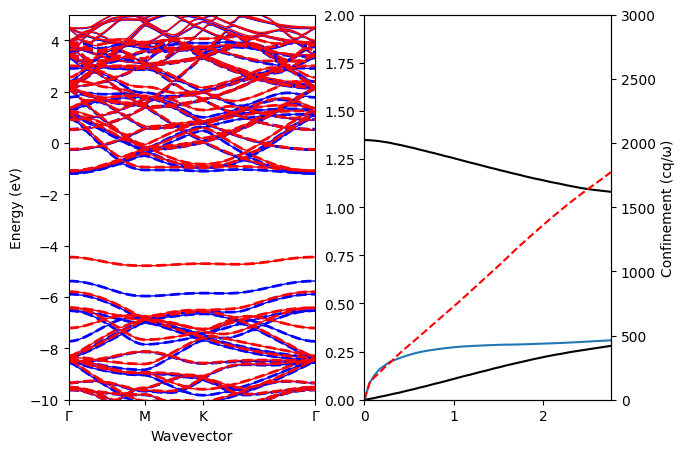

In [18]:
figure(figsize=(7, 5))
subplot(1, 2, 1)
plot_bands("../BN33NC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
plot_bands(HwannierUp, cell_mapUp, kpointsfile="../bandstruct.kpoints", linewidth=2, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cell_mapDn, kpointsfile="../bandstruct.kpoints", linewidth=2, color="red", linestyle="dashed")

xlim(0, 55)
ylim(-10, 0.1/eV)
ylim(-10, 5)

subplot(1, 2, 2)
plot([0, qs...]*10, [0, plasmon...])
plot(qs*10, landau_lower[1:50], color="black")
plot(qs*10, landau_upper[1:50], color="black")

ylim(0, 2)
xlim(0, maximum(qs)*10)
twinx()
plot([0, qs...]*10, [0, confinements...], color="red", linestyle="dashed")
ylim(0, 3e3)
ylabel("Confinement (cq/ω)")
xlabel("q (nm⁻¹")
savefig("BN33NC-Plasmon.pdf")

In [95]:
np.savetxt("Plasmon.txt", hcat(qs, plasmon, confinements))

In [20]:
np.savetxt("Landau.txt", hcat(qs, landau_lower[1:50], landau_upper[1:50]))

In [96]:
qs, plasmon, confinements = [x for x in eachcol(np.loadtxt("Plasmon.txt"))];

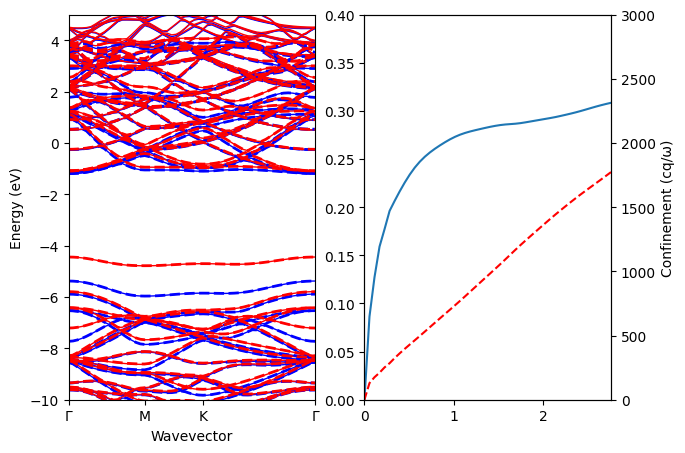

PyObject Text(0.5, 0, 'q (nm⁻¹')

In [97]:
figure(figsize=(7, 5))
subplot(1, 2, 1)
plot_bands("../BN33NC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
plot_bands(HwannierUp, cellmapUp, kpointsfile="../bandstruct.kpoints", linewidth=2, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cellmapDn, kpointsfile="../bandstruct.kpoints", linewidth=2, color="red", linestyle="dashed")

xlim(0, 55)
ylim(-10, 0.1/eV)
ylim(-10, 5)

subplot(1, 2, 2)
plot([0, qs...]*10, [0, plasmon...])
ylim(0, 0.4)
xlim(0, maximum(qs)*10)
twinx()
plot([0, qs...]*10, [0, confinements...], color="red", linestyle="dashed")
ylim(0, 3e3)
ylabel("Confinement (cq/ω)")
xlabel("q (nm⁻¹")
